In [70]:
import pandas as pd

df = pd.read_csv("../../datasets/salaries.csv")

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [51]:
import pandas as pd

df = pd.read_csv("../../datasets/salaries.csv")

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [54]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [55]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [56]:
df.drop_duplicates(inplace=True)

In [71]:
df = df[
    [
        'work_year',
        'experience_level',
        'employment_type',
        'job_title',
        'employee_residence',
        'remote_ratio',
        'company_location',
        'company_size',
        'salary_in_usd'
    ]
]

In [11]:
df.head()

,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_size,salary_in_usd
0,MI,FT,Data Scientist,DE,0,L,79833
1,SE,FT,Machine Learning Scientist,JP,0,S,260000
2,SE,FT,Big Data Engineer,GB,50,M,109024
3,MI,FT,Product Data Analyst,HN,0,S,20000
4,SE,FT,Machine Learning Engineer,US,50,L,150000


In [ ]:
df.shape


(607, 7)

In [59]:
experience_mapping = {
    'EN': 1,
    'MI': 3,
    'SE': 6,
    'EX': 10
}

df['experience_years'] = df['experience_level'].map(experience_mapping)
df.drop('experience_level', axis=1, inplace=True)

In [73]:
def categorize_role(role):

    role = role.lower()

    if 'data' in role:
        return 'Data'

    elif 'machine learning' in role or 'ml' in role:
        return 'AI'

    elif 'engineer' in role:
        return 'Engineering'

    elif 'analyst' in role:
        return 'Analytics'

    else:
        return 'Other'

df['role_category'] = df['job_title'].apply(categorize_role)
df.drop('job_title', axis=1, inplace=True)

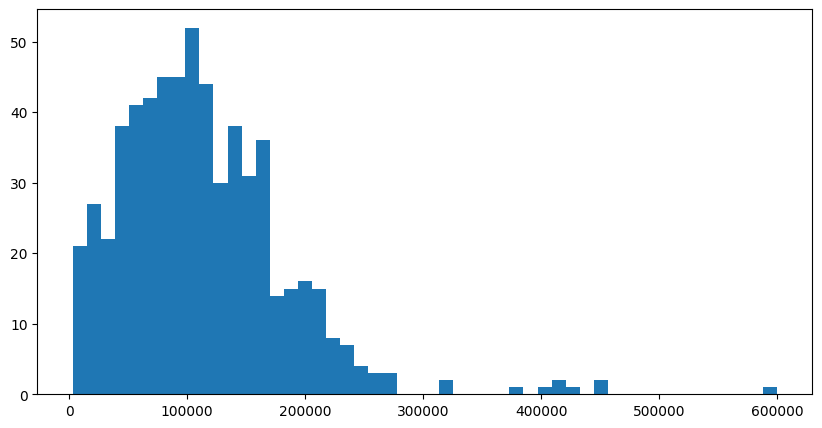

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['salary_in_usd'], bins=50)

plt.show()

In [107]:
Q1 = df['salary_in_usd'].quantile(0.25)

Q3 = df['salary_in_usd'].quantile(0.75)

IQR = Q3 - Q1

In [109]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['salary_in_usd'] >= lower_bound) &
    (df['salary_in_usd'] <= upper_bound)
]

In [118]:
import numpy as np

df['salary_in_usd'] = np.log1p(df['salary_in_usd'])

In [119]:
X = df.drop('salary_in_usd', axis=1)

y = df['salary_in_usd']

In [120]:
X = pd.get_dummies(X, drop_first=True)

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [122]:
print(X_train.shape)
print(X_test.shape)

(477, 118)
(120, 118)


In [123]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [134]:
predictions = model.predict(X_test)

In [135]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.3477983196312341
R2 Score: 0.4361010189305782


In [130]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [20, 25, 30],
    'min_samples_split': [2, 5],
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'max_depth': 25, 'min_samples_split': 5, 'n_estimators': 300}


In [136]:
best_model = grid_search.best_estimator_

In [137]:
predictions = best_model.predict(X_test)
predictions = np.expm1(predictions)

y_test_actual = np.expm1(y_test)

In [138]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test_actual, predictions)

print("MAE:", mae)
r2 = r2_score(y_test_actual, predictions)

print("R2 Score:", r2)

MAE: 29311.636805970007
R2 Score: 0.46786108044380803


In [127]:
import joblib

joblib.dump(model, "../model/salary_model.pkl")
joblib.dump(X.columns.tolist(), "../model/model_columns.pkl")

['../model/model_columns.pkl']

In [ ]:
mae = mean_absolute_error(y_test, xgb_predictions)

print("MAE:", mae)
r2 = r2_score(y_test, xgb_predictions)

print("R2 Score:", r2)

MAE: 28605.86328125
R2 Score: 0.5213955044746399
